# VLM Chain Grounding
**Pipeline**: Source frame → Qwen3-VL describes object → Destination frame → SAM3 Agent + Qwen3-VL grounding → comparison

| Section | Description |
|---------|-------------|
| 1. Setup | Imports, device, SAM3 model, VLM client |
| 2. Data | Load annotation, select frames |
| 3. VLM Description | Describe object in source frame |
| 4. Segmentation | SAM3 Agent · one-shot SAM3 · Qwen3-VL grounding |
| 5. Comparison | Overlap between SAM3 mask and VLM bboxes |

## 1. Setup

In [1]:
# 1.1 Imports
import os, sys, json, base64, ast, cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from pycocotools import mask as mask_util
from functools import partial
import torch

In [2]:
# 1.2 Device & SAM3 model
if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    device = torch.device('mps')
    torch.autocast('mps', dtype=torch.bfloat16).__enter__()
    print('Using MPS.')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.autocast('cuda', dtype=torch.bfloat16).__enter__()
    print('Using CUDA.')
else:
    device = torch.device('cpu')
    print('Using CPU.')

# Resolve SAM3_ROOT robustly regardless of CWD (examples/ or repo root)
_cwd = os.getcwd()
for _candidate in [_cwd, os.path.dirname(_cwd)]:
    if os.path.isdir(os.path.join(_candidate, 'sam3')):
        SAM3_ROOT = _candidate
        break
else:
    raise RuntimeError("Cannot locate SAM3 repo root. Run from examples/ or repo root.")

if SAM3_ROOT not in sys.path:
    sys.path.insert(0, SAM3_ROOT)
os.chdir(SAM3_ROOT)
print(f'SAM3_ROOT: {SAM3_ROOT}')

torch.inference_mode().__enter__()

import sam3
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.agent.client_sam3 import sam3_inference, call_sam_service as _call_sam_service
from sam3.agent.inference import run_single_image_inference

bpe_path = os.path.join(os.path.dirname(sam3.__file__), 'assets/bpe_simple_vocab_16e6.txt.gz')
sam3_model = build_sam3_image_model(bpe_path=bpe_path, device=str(device))
processor   = Sam3Processor(sam3_model, confidence_threshold=0.3, device=str(device))
print(f'SAM3 ready on {device}.')

Using MPS.
SAM3_ROOT: /Users/marcolomele/Documents/Repos/sam3


/Users/marcolomele/Documents/Repos/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
objc[23319]: Class SDLApplication is implemented in both /Users/marcolomele/miniconda3/envs/sam3_venv/lib/python3.11/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x1320e4890) and /Users/marcolomele/miniconda3/envs/sam3_venv/lib/python3.11/site-packages/decord/.dylibs/libSDL2-2.0.0.dylib (0x17621c800). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[23319]: Class SDLAppDelegate is implemented in both /Users/marcolomele/miniconda3/envs/sam3_venv/lib/python3.11/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x1320e48e0) and /Users/marcolomele/miniconda3/envs/sam3_venv/lib/python3.11/site-pack

SAM3 ready on mps.


In [3]:
# 1.3 VLM client  (Qwen3-VL via Ollama cloud)
from ollama import Client

# Load OLLAMA_API_KEY from env.env in repo root
_env_path = os.path.join(os.getcwd(), 'env.env')
if os.path.isfile(_env_path):
    with open(_env_path) as _f:
        for _line in _f:
            _line = _line.strip()
            if _line and not _line.startswith('#') and '=' in _line:
                _k, _v = _line.split('=', 1)
                os.environ[_k.strip()] = _v.strip().strip('"').strip("'")

OLLAMA_API_KEY = os.environ.get('OLLAMA_API_KEY', '')
VLM_MODEL      = 'qwen3-vl:235b-cloud'

vlm_client = Client(
    host='https://ollama.com',
    headers={'Authorization': f'Bearer {OLLAMA_API_KEY}'}
)
print('VLM client ready.')

VLM client ready.


In [17]:
def load_frame_and_mask(frame_str, cam, DATA_DIR, TAKE_UID, obj_masks):
    img_path = os.path.join(DATA_DIR, TAKE_UID, cam, f'{frame_str}.jpg')
    rgb      = np.array(Image.open(img_path).convert('RGB'))
    H, W     = rgb.shape[:2]
    rle      = obj_masks[cam][frame_str]
    mask     = mask_util.decode(rle).astype(bool)
    if mask.shape != (H, W):
        mask = np.array(
            Image.fromarray(mask.astype(np.uint8) * 255).resize((W, H), Image.NEAREST)
        ) > 127
    return img_path, rgb, mask

def overlay_mask(rgb, mask, alpha=0.45, color=(255, 80, 80)):
    out = rgb.copy().astype(float)
    for c, v in enumerate(color):
        out[..., c] = np.where(mask, out[..., c] * (1 - alpha) + v * alpha, out[..., c])
    return out.clip(0, 255).astype(np.uint8)

## 2. Data

In [18]:
# -- Step 2.1: Data paths -----------------------------------------------------
DATA_DIR  = os.path.join(SAM3_ROOT, "data/dev") 

assert os.path.isdir(DATA_DIR),   f"DATA_DIR not found: {DATA_DIR}"

rows = []
for take_uid in sorted(os.listdir(DATA_DIR)):
    ann_path = os.path.join(DATA_DIR, take_uid, "annotation.json")
    if not os.path.isfile(ann_path):
        continue
    with open(ann_path) as f:
        ann = json.load(f)
    for obj_name, cams in ann.get("masks", {}).items():
        for cam, frames in cams.items():
            rows.append((take_uid, obj_name, cam, len(frames)))

print(f"{'Take':<30}  {'Object':<30}  {'Camera':<25}  {'Frames':>6}")
print("\u2500" * 98)
for take, obj, cam, n in rows:
    print(f"{take:<30}  {obj:<30}  {cam:<25}  {n:>6}")
print(f"\n{len(rows)} (take, object, camera) combinations found.")
print("-> Set N_SAMPLES, RANDOM_SEED, DIRECTION in the next cell.")

Take                            Object                          Camera                     Frames
──────────────────────────────────────────────────────────────────────────────────────────────────
05e5f359-526d-4914-a86b-5a56cfcc0274  steel handle knife_0            aria01_214-1                  530
05e5f359-526d-4914-a86b-5a56cfcc0274  steel handle knife_0            cam01                         845
05e5f359-526d-4914-a86b-5a56cfcc0274  paper napkin_0                  cam03                         846
05e5f359-526d-4914-a86b-5a56cfcc0274  paper napkin_0                  aria01_214-1                  191
05e5f359-526d-4914-a86b-5a56cfcc0274  oyster sauce bottle_0           aria01_214-1                  671
05e5f359-526d-4914-a86b-5a56cfcc0274  oyster sauce bottle_0           cam01                         847
0efd9fc1-0f49-403d-9252-93f119a3ea3c  black_handle_knife_0            gp01                          345
0efd9fc1-0f49-403d-9252-93f119a3ea3c  black_handle_knife_0            aria0

Object  : 'oyster sauce bottle_0'
SRC 'gp03': 1069 frames  — first/last: 0 / 32100
DST 'aria01_214-1': 736 frames  — first/last: 210 / 31860
Source frame (largest mask) : 24810  (11,143 px)
Destination frame           : 24810
Source frame      : 24810
Destination frame : 24780
Source : (448, 796, 3)  |  GT mask: 484 px
Dest   : (448, 448, 3)  |  GT mask: 720 px


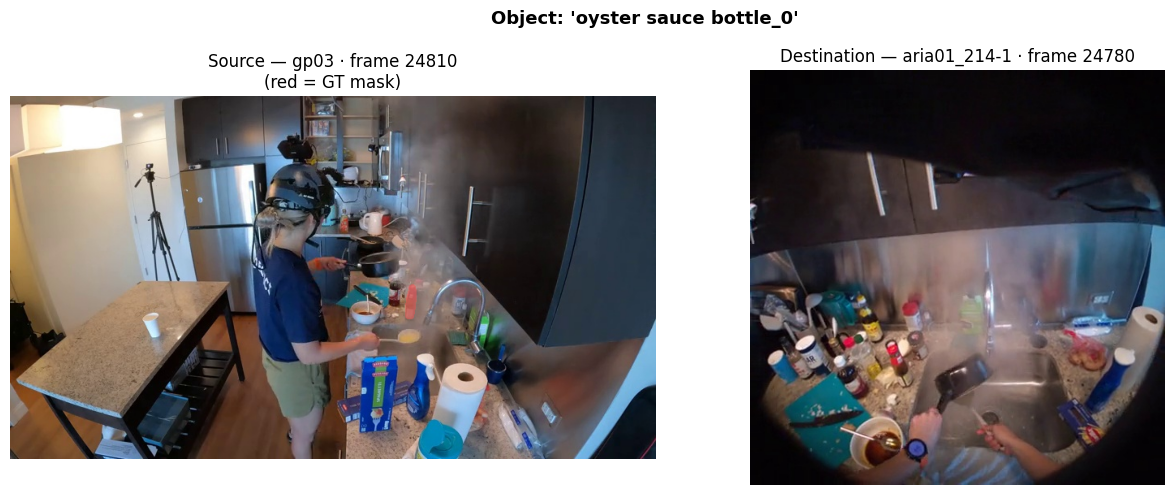

In [129]:
# 2.1 User inputs
# ── User inputs ─────────────────────────────────────────────────────────────
TAKE_UID = '8acb2112-465c-4088-b502-65fd9704dd77'
OBJ_NAME = 'oyster sauce bottle_0'
DST_CAM = 'aria01_214-1'                    
SRC_CAM  = 'gp03'          

# 2.2 Load annotation — inspect available objects, cameras, and frames
ann_path = os.path.join(DATA_DIR, TAKE_UID, 'annotation.json')

with open(ann_path) as f:
    ann = json.load(f)

masks_by_obj = ann['masks']   # {obj: {cam: {frame_str: rle}}}
assert OBJ_NAME in masks_by_obj, f"Object not found. Available: {list(masks_by_obj)}"

obj_masks  = masks_by_obj[OBJ_NAME]
src_frames = sorted(obj_masks[SRC_CAM].keys(), key=int)
dst_frames = sorted(obj_masks[DST_CAM].keys(), key=int)

print(f"Object  : '{OBJ_NAME}'")
print(f"SRC '{SRC_CAM}': {len(src_frames)} frames  — first/last: {src_frames[0]} / {src_frames[-1]}")
print(f"DST '{DST_CAM}': {len(dst_frames)} frames  — first/last: {dst_frames[0]} / {dst_frames[-1]}")

# Frame with largest source mask (by pixel count)
SRC_FRAME = DST_FRAME = max(src_frames, key=lambda f: mask_util.decode(obj_masks[SRC_CAM][f]).sum())
print(f"Source frame (largest mask) : {SRC_FRAME}  ({mask_util.decode(obj_masks[SRC_CAM][SRC_FRAME]).sum():,} px)")
print(f"Destination frame           : {DST_FRAME}")

# 2.3 Frame selection
if SRC_FRAME not in src_frames:
    # Get closest available by absolute difference (frame strings are ints)
    closest_src = min(src_frames, key=lambda x: abs(int(x) - int(SRC_FRAME)))
    print(f"WARNING: SRC_FRAME '{SRC_FRAME}' not found. Using closest available: '{closest_src}'.")
    SRC_FRAME = closest_src
if DST_FRAME not in dst_frames:
    closest_dst = min(dst_frames, key=lambda x: abs(int(x) - int(DST_FRAME)))
    print(f"WARNING: DST_FRAME '{DST_FRAME}' not found. Using closest available: '{closest_dst}'.")
    DST_FRAME = closest_dst

print(f"Source frame      : {SRC_FRAME}")
print(f"Destination frame : {DST_FRAME}")

# 2.4 Load frames & GT masks
src_img_path, src_rgb, src_mask = load_frame_and_mask(SRC_FRAME, SRC_CAM, DATA_DIR, TAKE_UID, obj_masks)
dst_img_path, dst_rgb, dst_mask = load_frame_and_mask(DST_FRAME, DST_CAM, DATA_DIR, TAKE_UID, obj_masks)

H_dst, W_dst = dst_rgb.shape[:2]
print(f"Source : {src_rgb.shape}  |  GT mask: {src_mask.sum():,} px")
print(f"Dest   : {dst_rgb.shape}  |  GT mask: {dst_mask.sum():,} px")

# 2.5 Visualize source & destination frames
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(overlay_mask(src_rgb, src_mask))
axes[0].set_title(f"Source — {SRC_CAM} · frame {SRC_FRAME}\n(red = GT mask)")
axes[0].axis('off')
axes[1].imshow(dst_rgb)
axes[1].set_title(f"Destination — {DST_CAM} · frame {DST_FRAME}")
axes[1].axis('off')
plt.suptitle(f"Object: '{OBJ_NAME}'", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. VLM: Describe Object in Source Frame
Draw a tight bounding box around the GT mask, then ask Qwen3-VL to describe it.

In [130]:
# 3.1 Helper functions
def create_bounding_box(img_path, mask_np, color=(255, 0, 0), scale=1.05):
    """Return PIL Image with a rotated minimum bounding box drawn over the masked object."""
    img = Image.open(img_path).convert('RGB')
    w, h = img.size
    if mask_np.shape[0] != h or mask_np.shape[1] != w:
        mask_np = cv2.resize(
            mask_np.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST
        ).astype(bool)
    mask_u8    = mask_np.astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    all_pts      = np.vstack(contours)
    rect         = cv2.minAreaRect(all_pts)
    cx, cy       = rect[0]; rw, rh = rect[1]; angle = rect[2]
    rect_scaled  = ((cx, cy), (rw * scale, rh * scale), angle)
    diagonal     = np.hypot(rw * scale, rh * scale)
    img_diag     = np.hypot(w, h)
    thickness    = max(1, min(4, int(round(diagonal / img_diag * 20))))
    box_pts      = cv2.boxPoints(rect_scaled).astype(np.intp)
    arr          = np.array(img)
    cv2.polylines(arr, [box_pts], isClosed=True, color=color, thickness=thickness)
    return Image.fromarray(arr)


def vlm_call(client, model, image_np, prompt, max_tokens=128):
    """Send numpy image + prompt to Ollama, return text."""
    _, buf   = cv2.imencode('.jpg', cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR))
    img_b64  = base64.b64encode(buf).decode()
    msgs     = [{'role': 'user', 'content': prompt, 'images': [img_b64]}]
    text     = ''
    for part in client.chat(model=model, messages=msgs, stream=True,
                            options={'num_predict': max_tokens}):
        text += part.message.content or ''
    return text.strip()


def parse_json_fence(text):
    """Strip markdown JSON fencing if present."""
    lines = text.splitlines()
    for i, line in enumerate(lines):
        if line.strip() == '```json':
            text = '\n'.join(lines[i + 1:]).split('```')[0]
            break
    return text.strip()


print('Helpers defined.')

Helpers defined.


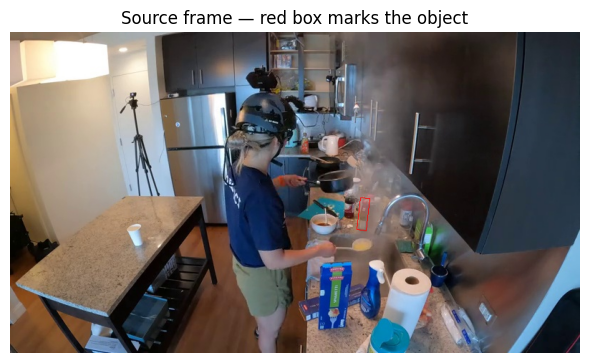

VLM raw output:
{
  "colour": "red",
  "object": "small bottle",
  "view_independent_descriptors": "cylindrical shape, smooth texture"
}


In [131]:
# 3.2 Annotate source frame and call VLM
VLM_PROMPT = """
Describe only the object exactly inside the red box.

Return exactly one valid JSON object and nothing else.

Schema:
{
  "colour": "<short color description>",
  "object": "<specific object name>",
  "view_independent_descriptors": "<view-independent descriptors>"
}

Rules:
- colour: only the boxed object's visible color(s)
- object: name the specific object
- view_independent_descriptors: only angle-independent descriptors (shape, texture, relations like on/under/held-by)
- Do not output markdown. Output JSON only.
"""

annotated_pil = create_bounding_box(src_img_path, src_mask)
annotated_np  = np.array(annotated_pil)

plt.figure(figsize=(6, 5))
plt.imshow(annotated_np)
plt.title('Source frame — red box marks the object')
plt.axis('off')
plt.tight_layout()
plt.show()

vlm_raw = vlm_call(vlm_client, VLM_MODEL, annotated_np, VLM_PROMPT, max_tokens=256)
print(f'VLM raw output:\n{vlm_raw}')

In [132]:
# 3.3 Parse description → compact text prompt for SAM3 / grounding
try:
    desc = json.loads(parse_json_fence(vlm_raw))
    vlm_description = (
        f"{desc.get('colour', '')} {desc.get('object', '')} "
        f"{desc.get('view_independent_descriptors', '')}"
    ).strip()
    print('Parsed fields:')
    for k, v in desc.items():
        print(f'  {k}: {v}')
except Exception as e:
    print(f'JSON parse failed ({e}). Using raw VLM output.')
    vlm_description = vlm_raw

print(f'\nDescription for downstream use:\n  "{vlm_description}"')

Parsed fields:
  colour: red
  object: small bottle
  view_independent_descriptors: cylindrical shape, smooth texture

Description for downstream use:
  "red small bottle cylindrical shape, smooth texture"


## 4. Segmentation in Destination View
Three parallel strategies — all seeded from the same VLM description produced above.

### 4a. SAM3 Agent
Full agentic loop: VLM reasons over SAM3 candidates until it picks the best mask.

In [ ]:
# 4a. SAM3 Agent
llm_config = {
    'provider': 'ollama',
    'model'   : VLM_MODEL,
    'host'    : 'https://ollama.com',
    'api_key' : OLLAMA_API_KEY,
    'name'    : 'ollama_cloud',
}

def _send_generate_request(messages):
    """Convert agent message list to a single Ollama call."""
    parts, images_b64 = [], []
    for msg in messages:
        role = msg.get('role')
        content = msg.get('content', [])
        if role == 'system' and isinstance(content, str):
            parts.append(content)
            continue
        if role not in ('user', 'system'):
            continue
        items = content if isinstance(content, list) else [{'type': 'text', 'text': content}]
        for c in items:
            if not isinstance(c, dict):
                continue
            if c.get('type') == 'text':
                parts.append(c.get('text', ''))
            elif c.get('type') == 'image' and 'image' in c:
                try:
                    with open(c['image'], 'rb') as fh:
                        images_b64.append(base64.b64encode(fh.read()).decode())
                except Exception as e:
                    print(f'Warning: could not load image {c["image"]}: {e}')
    prompt = '\n\n'.join(p for p in parts if p) or '(no text)'
    text   = ''
    for part in vlm_client.chat(
        model=VLM_MODEL,
        messages=[{'role': 'user', 'content': prompt, 'images': images_b64}],
        stream=True,
        options={'temperature': 0, 'seed': 777, 'num_predict': 2048},
    ):
        text += part.message.content or ''
    return text.strip()

_call_sam = partial(_call_sam_service, sam3_processor=processor)

agent_img_path = run_single_image_inference(
    dst_img_path, vlm_description, llm_config,
    _send_generate_request, _call_sam,
    output_dir='agent_output/vlm_grounding_exp', debug=True,
)

------------------------------ Starting SAM 3 Agent Session... ------------------------------ 
> Text prompt: red small bottle cylindrical shape, smooth texture
> Image path: /Users/marcolomele/Documents/Repos/sam3/data/dev/8acb2112-465c-4088-b502-65fd9704dd77/aria01_214-1/24780.jpg



------------------------------ Round 1------------------------------




>>> MLLM Response [start]
<tool> {"name": "segment_phrase", "parameters": {"text_prompt": "red bottle"}} </tool>
<<< MLLM Response [end]

🔍 Calling segment_phrase tool...
📞 Loading image '/Users/marcolomele/Documents/Repos/sam3/data/dev/8acb2112-465c-4088-b502-65fd9704dd77/aria01_214-1/24780.jpg' and sending with prompt 'red bottle'...
✅ Raw JSON response saved to 'vlm_sam3_agent_output/sam_out/run_20260327_203327_24780/Users-marcolomele-Documents-Repos-sam3-data-dev-8acb2112-465c-4088-b502-65fd9704dd77-aria01_214-1-24780.jpg/red bottle.json'
🔍 Rendering visualizations on the image ...
✅ Saved visualization at: vlm_sam3_agent_output

Agent output: vlm_sam3_agent_output/24780_red_small_bottle_cylindrical_shape,_smooth_texture_agent_ollama_cloud_pred.png


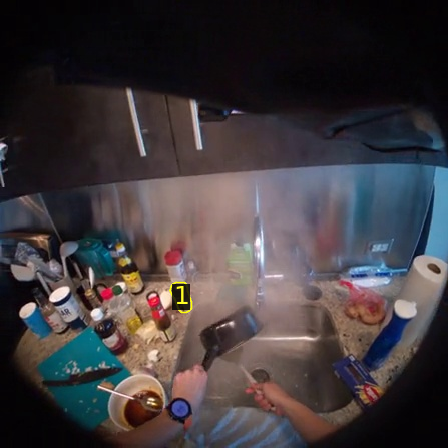

In [135]:
# Display agent result
from IPython.display import display as ipy_display, Image as ipy_Image

if agent_img_path and os.path.exists(agent_img_path):
    print(f'Agent output: {agent_img_path}')
    ipy_display(ipy_Image(filename=agent_img_path))
else:
    print('Agent output image not found — check vlm_sam3_agent_output/ directory.')

### 4b. One-shot SAM3
Bypass the agent — run SAM3 directly with a user-specified text prompt.
This re-enacts the final SAM3 call the agent makes before mask selection.

Running SAM3 with prompt: "bottle"
Found 18 mask(s).  Scores: ['0.625', '0.355', '0.801', '0.883', '0.785', '0.361', '0.914', '0.490', '0.578', '0.322', '0.520', '0.637', '0.387', '0.918', '0.613', '0.387', '0.910', '0.562']


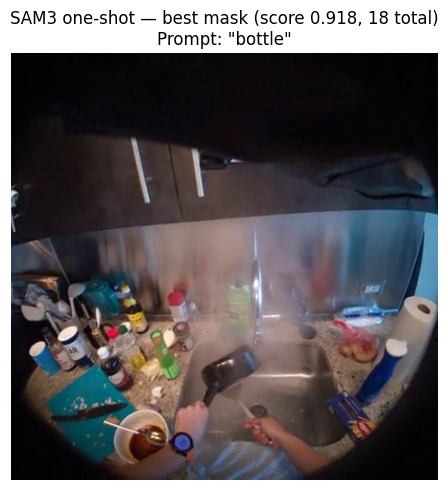

In [136]:
ONE_SHOT_PROMPT = 'bottle' 

# 4b. One-shot SAM3 — edit ONE_SHOT_PROMPT to experiment
print(f'Running SAM3 with prompt: "{ONE_SHOT_PROMPT}"')
sam3_result = sam3_inference(processor, dst_img_path, ONE_SHOT_PROMPT)

n_masks = len(sam3_result['pred_masks'])
print(f'Found {n_masks} mask(s).  Scores: {[f"{s:.3f}" for s in sam3_result["pred_scores"]]}')

# Decode best mask and visualize
def decode_sam3_mask(counts_str, h, w):
    """Reconstruct a boolean mask from a SAM3 RLE counts string."""
    for enc in (counts_str.encode('utf-8'), counts_str):
        try:
            return mask_util.decode({'counts': enc, 'size': [h, w]}).astype(bool)
        except Exception:
            continue
    return np.zeros((h, w), dtype=bool)


sam3_masks = [decode_sam3_mask(c, H_dst, W_dst) for c in sam3_result['pred_masks']]

if sam3_masks:
    best_idx  = int(np.argmax(sam3_result['pred_scores']))
    sam3_best = sam3_masks[best_idx]
    best_score = sam3_result['pred_scores'][best_idx]

    plt.figure(figsize=(8, 5))
    plt.imshow(overlay_mask(dst_rgb, sam3_best, color=(80, 210, 80)))
    plt.title(
        f'SAM3 one-shot — best mask (score {best_score:.3f}, {n_masks} total)\n'
        f'Prompt: "{ONE_SHOT_PROMPT}"'
    )
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No masks returned. Try lowering confidence_threshold or rephrasing the prompt.')
    sam3_best = np.zeros((H_dst, W_dst), dtype=bool)

### 4c. Qwen3-VL Grounding
Ask the VLM to *locate* the object in the destination frame using the structured description
produced in Section 3.  The model returns bounding boxes in 0-1000 normalised coordinates.

In [137]:
# 4c. Grounding — call Qwen3-VL with a locate prompt
GROUNDING_PROMPT = (
    f'locate every instance that belongs to the following description: "{vlm_description}". '
    f'Report bbox coordinates in JSON format.'
)

print(f'Grounding prompt:\n  {GROUNDING_PROMPT}\n')

grounding_raw = vlm_call(vlm_client, VLM_MODEL, dst_rgb, GROUNDING_PROMPT, max_tokens=512)
print(f'VLM grounding output:\n{grounding_raw}')

Grounding prompt:
  locate every instance that belongs to the following description: "red small bottle cylindrical shape, smooth texture". Report bbox coordinates in JSON format.

VLM grounding output:
```json
[
	{"bbox_2d": [325, 661, 368, 758], "label": "red small bottle cylindrical shape, smooth texture"}
]
```


Parsed 1 bounding box(es).


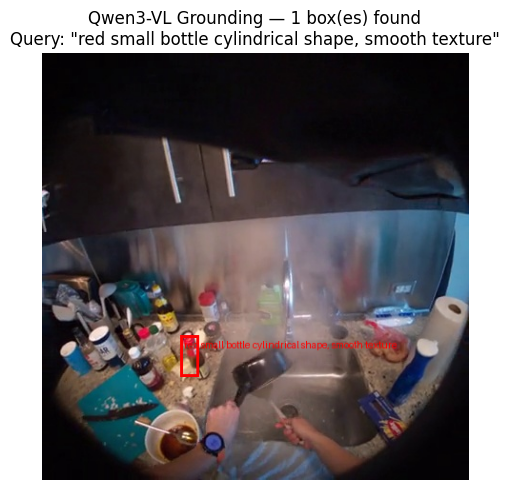

In [138]:
# Parse bboxes and visualize
def parse_grounding_bboxes(text):
    """Return list of {'bbox': [x1,y1,x2,y2], 'label': str} in 0-1000 scale."""
    text = parse_json_fence(text)
    for attempt in (text, text[:text.rfind('"}') + 2] + ']' if '"}' in text else text):
        try:
            data = ast.literal_eval(attempt)
            break
        except Exception:
            continue
    else:
        return []
    if not isinstance(data, list):
        data = [data]
    result = []
    for item in data:
        if isinstance(item, dict) and 'bbox_2d' in item:
            result.append({'bbox': item['bbox_2d'], 'label': item.get('label', '')})
    return result


def draw_grounding_bboxes(rgb, bboxes):
    """Draw grounding bboxes (0-1000 scale) on a copy of the image."""
    img  = Image.fromarray(rgb.copy())
    draw = ImageDraw.Draw(img)
    h, w = rgb.shape[:2]
    palette = ['red', 'lime', 'blue', 'yellow', 'cyan', 'magenta']
    for i, item in enumerate(bboxes):
        color = palette[i % len(palette)]
        x1, y1, x2, y2 = item['bbox']
        ax1, ay1 = int(x1 / 1000 * w), int(y1 / 1000 * h)
        ax2, ay2 = int(x2 / 1000 * w), int(y2 / 1000 * h)
        draw.rectangle([(ax1, ay1), (ax2, ay2)], outline=color, width=3)
        if item.get('label'):
            draw.text((ax1 + 4, ay1 + 4), item['label'], fill=color)
    return np.array(img)


grounding_bboxes = parse_grounding_bboxes(grounding_raw)
print(f'Parsed {len(grounding_bboxes)} bounding box(es).')

plt.figure(figsize=(8, 5))
plt.imshow(draw_grounding_bboxes(dst_rgb, grounding_bboxes))
plt.title(
    f'Qwen3-VL Grounding — {len(grounding_bboxes)} box(es) found\n'
    f'Query: "{vlm_description}"'
)
plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Comparison
Overlay SAM3 mask (4b) and Qwen3-VL grounding boxes (4c) on the destination frame,
and compute IoU against the GT mask.

IoU — Agent         : 0.000
IoU — SAM3          : 0.866
IoU — Grounding     : 0.393
IoU — Union         : 0.617
IoU — Intersection  : 0.550


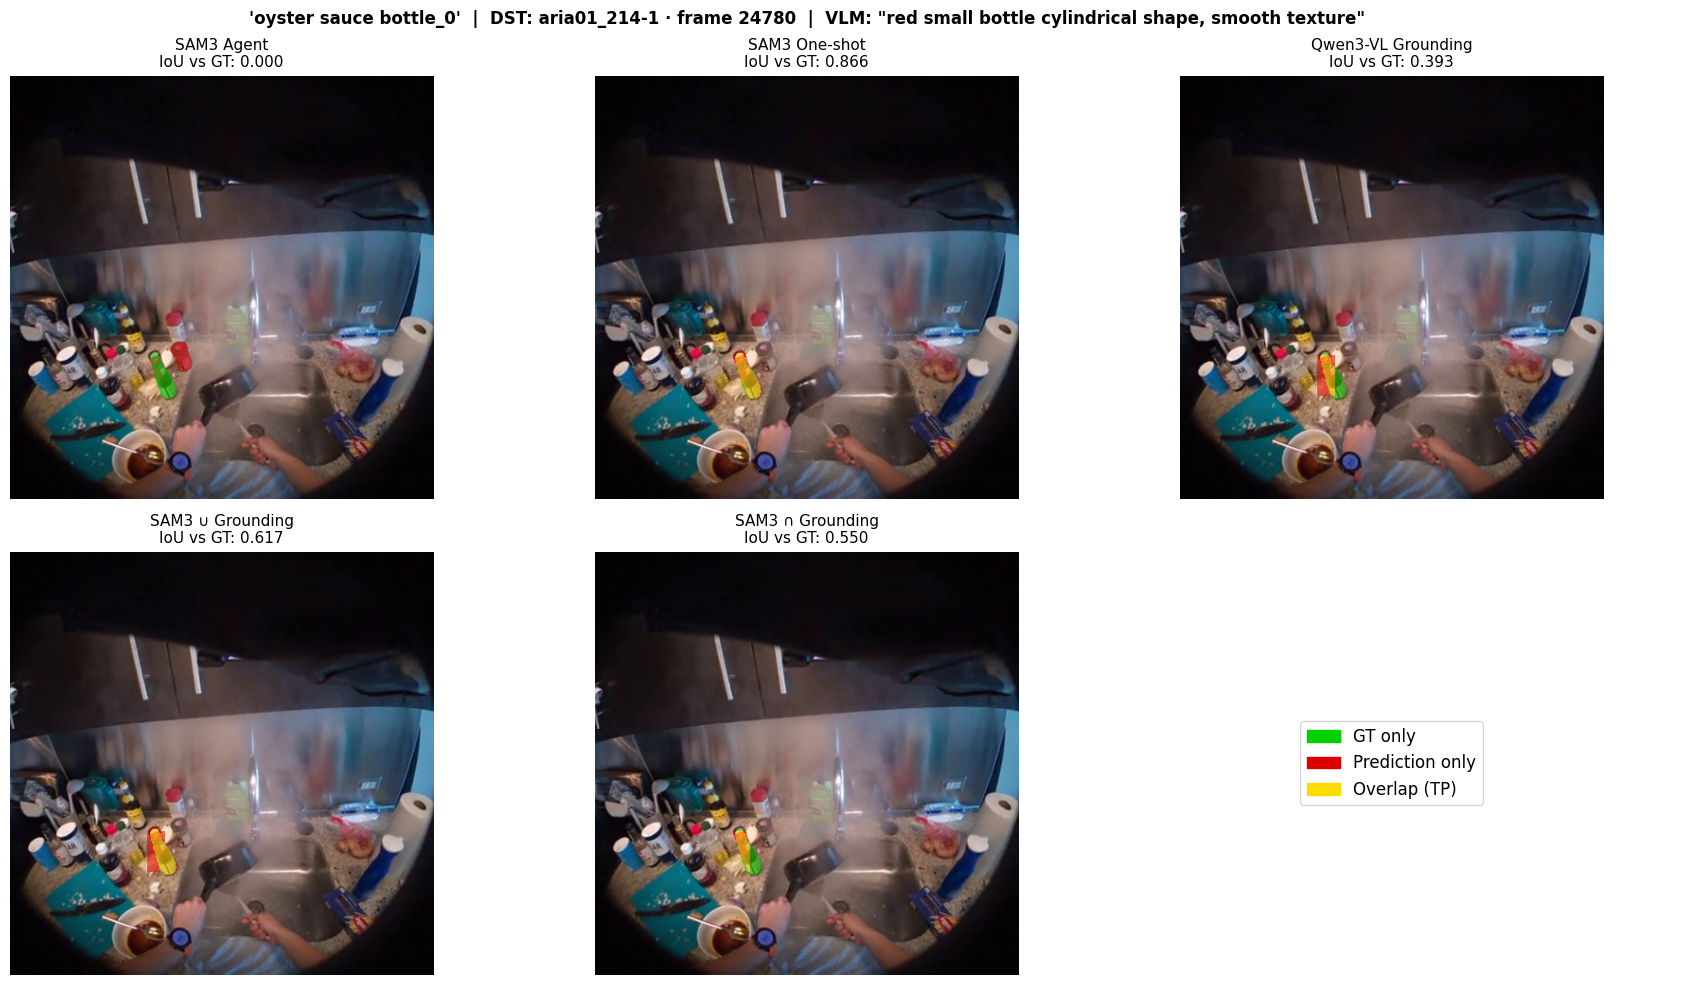

In [139]:
# 5a. Overlap: SAM3 mask vs grounding bboxes vs GT

# ── Build grounding union mask ────────────────────────────────────────────────
grounding_mask = np.zeros((H_dst, W_dst), dtype=bool)
for item in grounding_bboxes:
    x1, y1, x2, y2 = item['bbox']
    ax1, ay1 = int(x1 / 1000 * W_dst), int(y1 / 1000 * H_dst)
    ax2, ay2 = int(x2 / 1000 * W_dst), int(y2 / 1000 * H_dst)
    grounding_mask[ay1:ay2, ax1:ax2] = True

# ── Load agent best mask from saved JSON ─────────────────────────────────────
agent_mask = np.zeros((H_dst, W_dst), dtype=bool)
if agent_img_path and os.path.exists(agent_img_path):
    agent_json_path = agent_img_path.replace('.png', '.json')
    if os.path.exists(agent_json_path):
        with open(agent_json_path) as f:
            agent_out = json.load(f)
        _masks  = agent_out.get('pred_masks', [])
        _scores = agent_out.get('pred_scores', [])
        _h = agent_out.get('orig_img_h', H_dst)
        _w = agent_out.get('orig_img_w', W_dst)
        if _masks:
            best = int(np.argmax(_scores)) if _scores else 0
            agent_mask = decode_sam3_mask(_masks[best], _h, _w)
            if agent_mask.shape != (H_dst, W_dst):
                agent_mask = np.array(
                    Image.fromarray(agent_mask.astype(np.uint8)*255).resize((W_dst, H_dst), Image.NEAREST)
                ) > 127

# ── IoU metrics ───────────────────────────────────────────────────────────────
def iou(a, b):
    inter = (a & b).sum()
    union = (a | b).sum()
    return inter / union if union > 0 else 0.0

intersection_mask = sam3_best & grounding_mask

metrics = {
    'Agent'       : iou(agent_mask,                    dst_mask),
    'SAM3'        : iou(sam3_best,                     dst_mask),
    'Grounding'   : iou(grounding_mask,                dst_mask),
    'Union'       : iou(sam3_best | grounding_mask,    dst_mask),
    'Intersection': iou(intersection_mask,             dst_mask),
}
for k, v in metrics.items():
    print(f'IoU — {k:<14}: {v:.3f}')

# ── Composite helper ──────────────────────────────────────────────────────────
def make_composite(rgb, pred_mask, gt_mask):
    """Green=GT only · Red=pred only · Yellow=overlap."""
    comp = rgb.copy().astype(float)
    a = 0.55
    only_gt   = gt_mask   & ~pred_mask
    only_pred = pred_mask & ~gt_mask
    overlap   = pred_mask &  gt_mask
    for c, v in enumerate((0, 210, 0)):   comp[..., c] = np.where(only_gt,   comp[..., c]*(1-a) + v*a, comp[..., c])
    for c, v in enumerate((220, 0, 0)):   comp[..., c] = np.where(only_pred, comp[..., c]*(1-a) + v*a, comp[..., c])
    for c, v in enumerate((255, 220, 0)): comp[..., c] = np.where(overlap,   comp[..., c]*(1-a) + v*a, comp[..., c])
    return comp.clip(0, 255).astype(np.uint8)

# ── 2-row plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

panels = [
    (axes[0, 0], agent_mask,                    'SAM3 Agent',         metrics['Agent']),
    (axes[0, 1], sam3_best,                     'SAM3 One-shot',      metrics['SAM3']),
    (axes[0, 2], grounding_mask,                'Qwen3-VL Grounding', metrics['Grounding']),
    (axes[1, 0], sam3_best | grounding_mask,    'SAM3 ∪ Grounding',   metrics['Union']),
    (axes[1, 1], intersection_mask,             'SAM3 ∩ Grounding',   metrics['Intersection']),
]
for ax, pred, title, iou_val in panels:
    ax.imshow(make_composite(dst_rgb, pred, dst_mask))
    ax.set_title(f'{title}\nIoU vs GT: {iou_val:.3f}', fontsize=11)
    ax.axis('off')

axes[1, 2].axis('off')
axes[1, 2].legend(
    handles=[
        plt.Rectangle((0,0),1,1, color=(0, 210/255, 0)),
        plt.Rectangle((0,0),1,1, color=(220/255, 0, 0)),
        plt.Rectangle((0,0),1,1, color=(1, 220/255, 0)),
    ],
    labels=['GT only', 'Prediction only', 'Overlap (TP)'],
    loc='center', fontsize=12, framealpha=0.8,
)

plt.suptitle(
    f"'{OBJ_NAME}'  |  DST: {DST_CAM} · frame {DST_FRAME}  |  VLM: \"{vlm_description}\"",
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.show()